In [1]:
%load_ext autoreload
%autoreload 2
# standard imports
import pandas as pd
import numpy as np
import sys

sys.path.append("..")

In [2]:
from models.prepare import prepare_df

safe_to_drop = ["author_qid", "goodreads_id", "title", "authorLabel"]
shortlists = pd.read_csv("../data/train_novels.csv").drop(columns=safe_to_drop)

df_train = prepare_df(shortlists)
X_train = df_train.copy()
y_train = X_train.pop("n_win")


In [3]:
from sklearn.metrics import f1_score
from models.naive import naive_win_counts

N_baseline_runs = 1000
baseline_f1s = np.zeros(N_baseline_runs)

for i in range(N_baseline_runs):
    baseline_f1s[i] = f1_score(y_train > 0, naive_win_counts(df_train) > 0)

In [4]:
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import GroupKFold
from sklearn.base import BaseEstimator
from models.transformers import RowCountEncoder, impute_topicality, cohort_zscore


def build_pipeline(estimator_name: str, estimator: BaseEstimator) -> Pipeline:
    return Pipeline(
        [
            ("impute_topicality", FunctionTransformer(impute_topicality)),
            (
                "encode_author_data",
                RowCountEncoder(["gender", "birth_country"], "work_qid"),
            ),
            (
                "zscore",
                FunctionTransformer(
                    cohort_zscore,
                    kw_args={"columns": ["awards_as_of_year", "topicality"]},
                ),
            ),
            (
                "drop",
                FunctionTransformer(lambda df: df.drop(columns=["work_qid", "month"])),
            ),
            ("imputer", SimpleImputer(strategy="median")),
            (
                estimator_name,
                estimator,
            ),
        ]
    ).set_output(transform="pandas")


In [5]:
from sklearn.model_selection import TunedThresholdClassifierCV, cross_validate
from sklearn import config_context

with config_context(enable_metadata_routing=True):
    logistic_model = TunedThresholdClassifierCV(
        build_pipeline(
            "logistic",
            LogisticRegressionCV(
                max_iter=10000,
                fit_intercept=False,
                class_weight="balanced",
                solver="liblinear",
                scoring="roc_auc",
            ).set_fit_request(sample_weight=True),
        ),
        scoring="f1",
    )

    logistic_f1s = cross_validate(
        logistic_model,
        X_train,
        y_train > 0,
        cv=GroupKFold(n_splits=5),
        scoring="f1",
        params={"groups": X_train["year"], "sample_weight": X_train["n_nom_all"]},
    )["test_score"]

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

with config_context(enable_metadata_routing=True):
    splitter = GroupKFold(n_splits=5)

    dt_model = TunedThresholdClassifierCV(
        build_pipeline(
            "tree",
            GridSearchCV(
                DecisionTreeClassifier(min_samples_leaf=4, class_weight="balanced"),
                param_grid={"max_depth": range(1, 10)},
                cv=splitter,
            ),
        ),
        scoring="f1",
    )

    dt_f1s = cross_validate(
        dt_model,
        X_train,
        y_train > 0,
        cv=splitter,
        scoring="f1",
        params={"groups": X_train["year"]},
    )["test_score"]

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold

with config_context(enable_metadata_routing=True):
    splitter = StratifiedGroupKFold(n_splits=5)

    rf_model = TunedThresholdClassifierCV(
        build_pipeline(
            "tree",
            GridSearchCV(
                RandomForestClassifier(class_weight="balanced"),
                param_grid={"max_depth": range(1, 10), "n_estimators": [100, 500]},
                scoring="roc_auc",
                cv=splitter,
                n_jobs=2,
            ),
        ),
        scoring="f1",
    )

    rf_f1s = cross_validate(
        rf_model,
        X_train,
        y_train > 0,
        cv=splitter,
        scoring="f1",
        params={"groups": X_train["year"]},
        n_jobs=5,
    )["test_score"]

In [8]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedGroupKFold

with config_context(enable_metadata_routing=True):
    splitter = StratifiedGroupKFold(n_splits=5)

    xgb_model = TunedThresholdClassifierCV(
        build_pipeline(
            "tree",
            GridSearchCV(
                XGBClassifier(),
                param_grid={"max_depth": range(1, 10), "n_estimators": [100, 500]},
                scoring="roc_auc",
                cv=splitter,
                n_jobs=2,
            ),
        ),
        scoring="f1",
    )

    xgb_f1s = cross_validate(
        xgb_model,
        X_train,
        y_train > 0,
        cv=splitter,
        scoring="f1",
        params={"groups": X_train["year"]},
        n_jobs=5,
    )["test_score"]

Text(0, 0.5, '$F_1$')

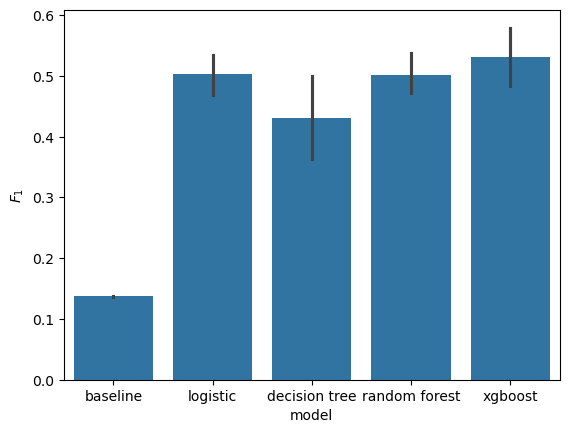

In [9]:
import seaborn as sns
f1_scores = {
    "baseline": baseline_f1s,
    "logistic": logistic_f1s,
    "decision tree": dt_f1s,
    "random forest": rf_f1s,
    "xgboost": xgb_f1s,
}
performance = pd.concat([
    pd.DataFrame({
        "model": k,
        "f1": v

    })
    for (k, v) in f1_scores.items()
])
performance

f1_plot = sns.barplot(data=performance, x="model", y="f1")
f1_plot.set_ylabel(r"$F_1$")